In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# lets see if theres any correllation between rainfall and water Level
weather_df = pd.read_csv("valid_data/weather.csv")
hydro_df = pd.read_csv("valid_data/hydrometric.csv")

In [11]:
print(weather_df.head())
print(len(weather_df))

         Date      Station Name   Latitude   Longitude  MIN_TEMPERATURE  \
0  2013-01-01  CAMPBELL RIVER A  49.951944 -125.273056              1.2   
1  2013-01-02  CAMPBELL RIVER A  49.951944 -125.273056              0.0   
2  2013-01-03  CAMPBELL RIVER A  49.951944 -125.273056              0.8   
3  2013-01-04  CAMPBELL RIVER A  49.951944 -125.273056              1.3   
4  2013-01-05  CAMPBELL RIVER A  49.951944 -125.273056              1.3   

   MAX_TEMPERATURE  MEAN_TEMPERATURE  TOTAL_PRECIPITATION  TOTAL_RAIN  \
0              3.1               2.2                  0.0         0.0   
1              3.4               1.7                  0.0         0.0   
2              2.7               1.8                  1.6         1.6   
3              5.2               3.3                  6.8         6.8   
4              5.8               3.6                  7.4         7.4   

   TOTAL_SNOW  SNOW_ON_GROUND  match key  
0         0.0             3.0          1  
1         0.0           

In [12]:
# discrepency is length is okay since the same weather station is associated with two different hydrometric stations
print(hydro_df.head())
print(len(hydro_df))

         Date Station ID                  Station Name  Latitude  Longitude  \
0  2013-01-01    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
1  2013-01-02    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
2  2013-01-03    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
3  2013-01-04    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   
4  2013-01-05    08HB006  PUNTLEDGE RIVER AT COURTENAY  49.68803 -125.03419   

   Daily Discharge  Daily Water Level  match key  
0             23.2             20.153          2  
1             21.3             20.126          2  
2             20.9             20.120          2  
3             21.0             20.122          2  
4             21.8             20.133          2  
16068


In [80]:
# get the subset we're interested in doing analysis on (in this case total rain and water level)
rain_data = weather_df[["Date","Station Name","TOTAL_RAIN","TOTAL_PRECIPITATION","MEAN_TEMPERATURE",
            "TOTAL_SNOW","MIN_TEMPERATURE","MAX_TEMPERATURE","SNOW_ON_GROUND", "match key"]]
level_data = hydro_df[["Date","Station Name","Daily Discharge","Daily Water Level","match key"]]

In [81]:
# get the data for a single matched station
rain_data_0 = rain_data[rain_data["match key"] == 2]
level_data_0 = level_data[level_data["match key"] == 2]

In [82]:
rain_data_0

,Date,Station Name,TOTAL_RAIN,TOTAL_PRECIPITATION,MEAN_TEMPERATURE,TOTAL_SNOW,MIN_TEMPERATURE,MAX_TEMPERATURE,SNOW_ON_GROUND,match key
4017,2013-01-01,COURTENAY PUNTLEDGE,0.0,0.0,2.0,0.0,0.0,4.0,2.0,2
4018,2013-01-02,COURTENAY PUNTLEDGE,0.0,0.0,2.3,0.0,0.0,4.5,2.0,2
4019,2013-01-03,COURTENAY PUNTLEDGE,2.4,2.4,1.6,0.0,-0.5,3.8,2.0,2
4020,2013-01-04,COURTENAY PUNTLEDGE,3.0,3.0,3.3,0.0,0.5,6.0,2.0,2
4021,2013-01-05,COURTENAY PUNTLEDGE,2.2,2.2,3.8,0.0,1.0,6.5,0.0,2
...,...,...,...,...,...,...,...,...,...,...
8029,2023-12-27,COURTENAY PUNTLEDGE,24.4,24.4,6.5,0.0,3.0,10.0,0.0,2
8030,2023-12-28,COURTENAY PUNTLEDGE,19.2,19.2,6.0,0.0,2.0,10.0,0.0,2
8031,2023-12-29,COURTENAY PUNTLEDGE,11.9,11.9,7.0,0.0,3.0,11.0,0.0,2
8032,2023-12-30,COURTENAY PUNTLEDGE,11.9,11.9,7.0,0.0,3.0,11.0,0.0,2


In [83]:
level_data_0

,Date,Station Name,Daily Discharge,Daily Water Level,match key
0,2013-01-01,PUNTLEDGE RIVER AT COURTENAY,23.2,20.153,2
1,2013-01-02,PUNTLEDGE RIVER AT COURTENAY,21.3,20.126,2
2,2013-01-03,PUNTLEDGE RIVER AT COURTENAY,20.9,20.120,2
3,2013-01-04,PUNTLEDGE RIVER AT COURTENAY,21.0,20.122,2
4,2013-01-05,PUNTLEDGE RIVER AT COURTENAY,21.8,20.133,2
...,...,...,...,...,...
4012,2023-12-27,PUNTLEDGE RIVER AT COURTENAY,169.0,21.073,2
4013,2023-12-28,PUNTLEDGE RIVER AT COURTENAY,205.0,21.214,2
4014,2023-12-29,PUNTLEDGE RIVER AT COURTENAY,293.0,21.533,2
4015,2023-12-30,PUNTLEDGE RIVER AT COURTENAY,284.0,21.512,2


In [84]:
combine0 = rain_data_0.merge(level_data_0, on="Date")

In [85]:
combine0

,Date,Station Name_x,TOTAL_RAIN,TOTAL_PRECIPITATION,MEAN_TEMPERATURE,TOTAL_SNOW,MIN_TEMPERATURE,MAX_TEMPERATURE,SNOW_ON_GROUND,match key_x,Station Name_y,Daily Discharge,Daily Water Level,match key_y
0,2013-01-01,COURTENAY PUNTLEDGE,0.0,0.0,2.0,0.0,0.0,4.0,2.0,2,PUNTLEDGE RIVER AT COURTENAY,23.2,20.153,2
1,2013-01-02,COURTENAY PUNTLEDGE,0.0,0.0,2.3,0.0,0.0,4.5,2.0,2,PUNTLEDGE RIVER AT COURTENAY,21.3,20.126,2
2,2013-01-03,COURTENAY PUNTLEDGE,2.4,2.4,1.6,0.0,-0.5,3.8,2.0,2,PUNTLEDGE RIVER AT COURTENAY,20.9,20.120,2
3,2013-01-04,COURTENAY PUNTLEDGE,3.0,3.0,3.3,0.0,0.5,6.0,2.0,2,PUNTLEDGE RIVER AT COURTENAY,21.0,20.122,2
4,2013-01-05,COURTENAY PUNTLEDGE,2.2,2.2,3.8,0.0,1.0,6.5,0.0,2,PUNTLEDGE RIVER AT COURTENAY,21.8,20.133,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,2023-12-27,COURTENAY PUNTLEDGE,24.4,24.4,6.5,0.0,3.0,10.0,0.0,2,PUNTLEDGE RIVER AT COURTENAY,169.0,21.073,2
4013,2023-12-28,COURTENAY PUNTLEDGE,19.2,19.2,6.0,0.0,2.0,10.0,0.0,2,PUNTLEDGE RIVER AT COURTENAY,205.0,21.214,2
4014,2023-12-29,COURTENAY PUNTLEDGE,11.9,11.9,7.0,0.0,3.0,11.0,0.0,2,PUNTLEDGE RIVER AT COURTENAY,293.0,21.533,2
4015,2023-12-30,COURTENAY PUNTLEDGE,11.9,11.9,7.0,0.0,3.0,11.0,0.0,2,PUNTLEDGE RIVER AT COURTENAY,284.0,21.512,2


In [92]:
import matplotlib.ticker as ticker
import seaborn
seaborn.set()

In [ ]:
[["TOTAL_RAIN","TOTAL_PRECIPITATION","MEAN_TEMPERATURE",
            "TOTAL_SNOW","MIN_TEMPERATURE","MAX_TEMPERATURE","SNOW_ON_GROUND","Daily Discharge","Daily Water Level"]]

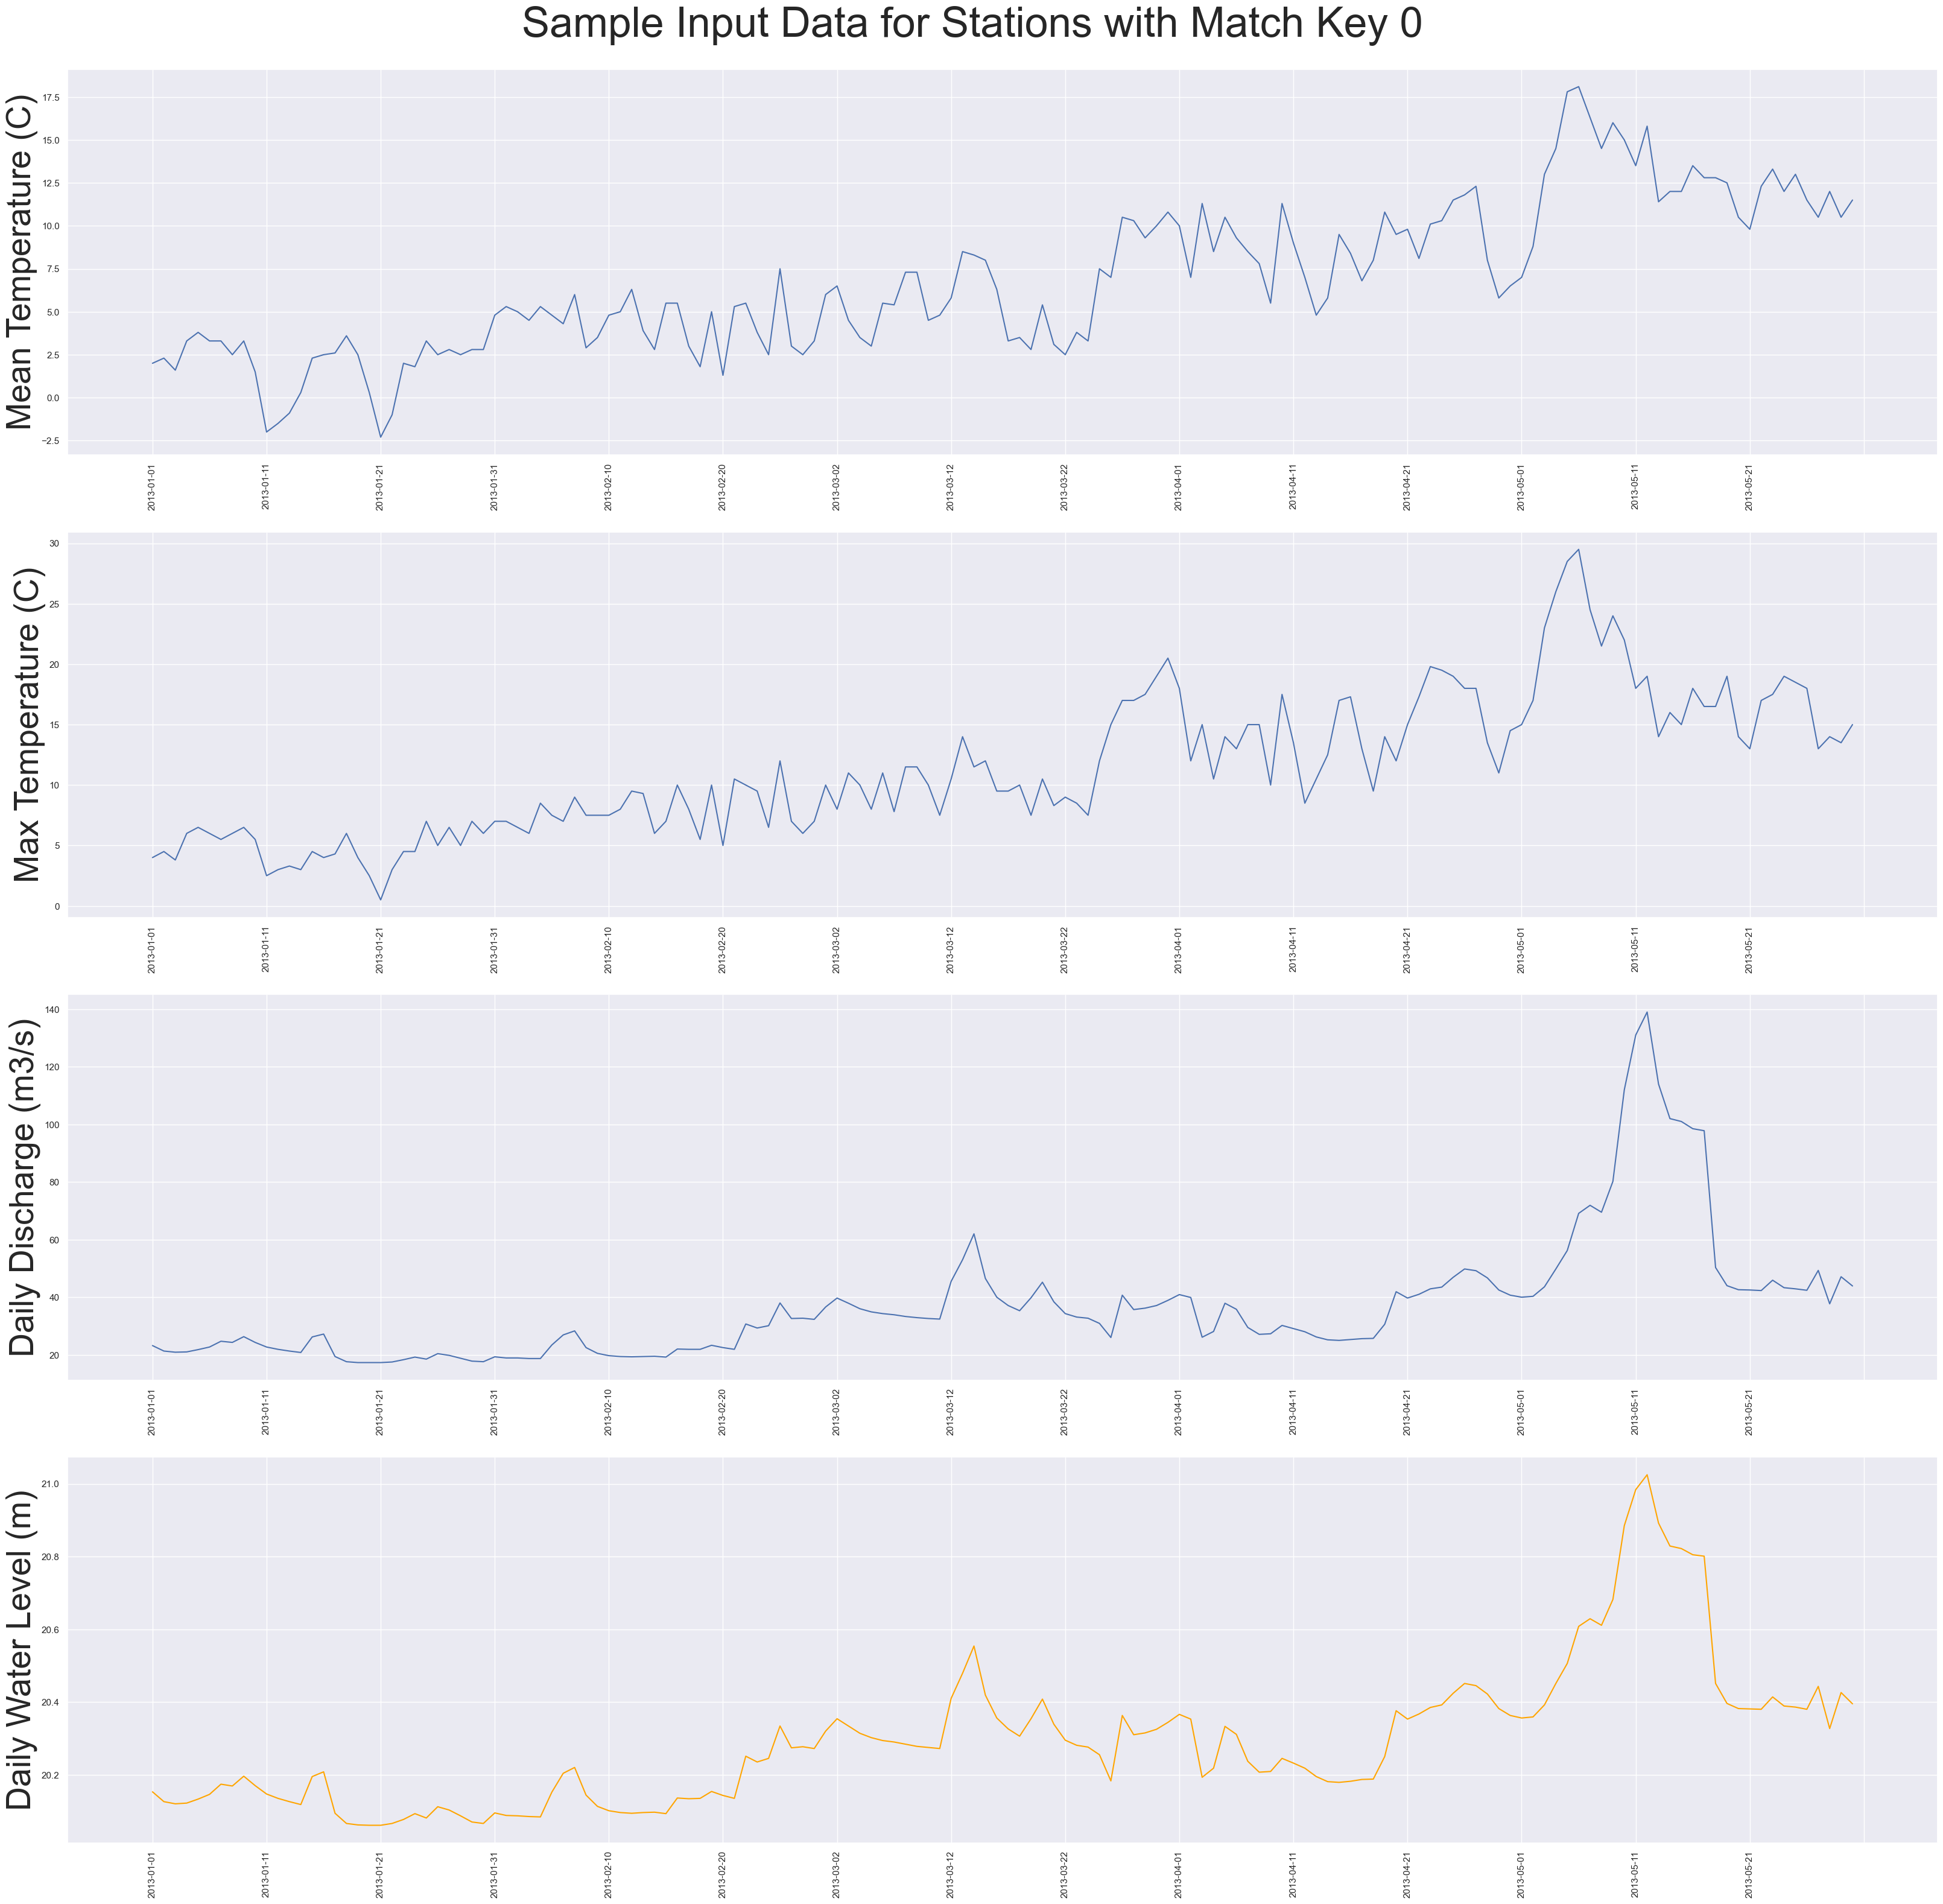

In [ ]:
date_range = pd.date_range(start="1/1/2013", end="31/12/2013", freq='W')
fig, axs = plt.subplots(5, figsize=(40,90))
plt.rcParams['axes.labelsize']=40
space = 10
x = 150
# TOTAL_PRECIPITATION
axs[0].plot(combine0["Date"][:x], combine0["TOTAL_PRECIPITATION"][:x])
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[0].tick_params('x', labelrotation=90)
axs[0].set_ylabel("Total Precipitation (cm)")
# TOTAL_RAIN
axs[1].plot(combine0["Date"][:x], combine0["TOTAL_RAIN"][:x])
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[1].tick_params('x', labelrotation=90)
axs[1].set_ylabel("Total Rain (cm)")
# TOTAL_SNOW
axs[2].plot(combine0["Date"][:x], combine0["TOTAL_SNOW"][:x])
axs[2].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[2].tick_params('x', labelrotation=90)
axs[2].set_ylabel("Total Snow (cm)")
# SNOW_ON_GROUND
axs[3].plot(combine0["Date"][:x], combine0["SNOW_ON_GROUND"][:x])
axs[3].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[3].tick_params('x', labelrotation=90)
axs[3].set_ylabel("Snow on Ground (cm)")
# MIN_TEMPERATURE
axs[4].plot(combine0["Date"][:x], combine0["MIN_TEMPERATURE"][:x])
axs[4].tick_params('x', labelrotation=90)
axs[4].set_ylabel("Min Temperature (C)")
axs[4].xaxis.set_major_locator(ticker.MultipleLocator(space))
# MEAN_TEMPERATURE
axs[5].plot(combine0["Date"][:x], combine0["MEAN_TEMPERATURE"][:x])
axs[5].tick_params('x', labelrotation=90)
axs[5].set_ylabel("Mean Temperature (C)")
axs[5].xaxis.set_major_locator(ticker.MultipleLocator(space))
# MAX_TEMPERATURE
axs[6].plot(combine0["Date"][:x], combine0["MAX_TEMPERATURE"][:x])
axs[6].tick_params('x', labelrotation=90)
axs[6].set_ylabel("Max Temperature (C)")
axs[6].xaxis.set_major_locator(ticker.MultipleLocator(space))
# Daily Discharge
axs[7].plot(combine0["Date"][:x], combine0["Daily Discharge"][:x])
axs[7].tick_params('x', labelrotation=90)
axs[7].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[7].set_ylabel("Daily Discharge (m3/s)")
# Daily Water Level // should be last plot
axs[8].plot(combine0["Date"][:x], combine0["Daily Water Level"][:x], color="orange")
axs[8].tick_params('x', labelrotation=90)
axs[8].xaxis.set_major_locator(ticker.MultipleLocator(space))
axs[8].set_ylabel("Daily Water Level (m)")

# fig.tight_layout()
fig.subplots_adjust(top=0.95)
fig.suptitle("Sample Input Data for Stations with Match Key 0", fontsize=50)

plt.show()

In [19]:
ml_data = combine0[["Date","TOTAL_RAIN","TOTAL_SNOW","MEAN_TEMPERATURE","SNOW_ON_GROUND","Daily Discharge","Daily Water Level"]]

In [20]:
ml_data["y"] = ml_data["Daily Water Level"].shift(-1)

C:\Users\Chris\AppData\Local\Temp\ipykernel_39056\3387291769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data["y"] = ml_data["Daily Water Level"].shift(-1)


In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor

In [22]:
ml_data

,Date,TOTAL_RAIN,TOTAL_SNOW,MEAN_TEMPERATURE,SNOW_ON_GROUND,Daily Discharge,Daily Water Level,y
0,2013-01-01,0.0,0.0,2.0,2.0,23.2,20.153,20.126
1,2013-01-02,0.0,0.0,2.3,2.0,21.3,20.126,20.120
2,2013-01-03,2.4,0.0,1.6,2.0,20.9,20.120,20.122
3,2013-01-04,3.0,0.0,3.3,2.0,21.0,20.122,20.133
4,2013-01-05,2.2,0.0,3.8,0.0,21.8,20.133,20.146
...,...,...,...,...,...,...,...,...
4012,2023-12-27,24.4,0.0,6.5,0.0,169.0,21.073,21.214
4013,2023-12-28,19.2,0.0,6.0,0.0,205.0,21.214,21.533
4014,2023-12-29,11.9,0.0,7.0,0.0,293.0,21.533,21.512
4015,2023-12-30,11.9,0.0,7.0,0.0,284.0,21.512,21.419


## This seems to do decent!

In [66]:
# X = ml_data[["TOTAL_RAIN","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
# y = ml_data["y"]

ml_data = ml_data.iloc[:-1]

# dont use random train test split, order matters, time series data
# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, shuffle=False)
# TODO ideally, we can organize data by season, so we can predict based on station and season, but that would require
# a 40 year span to get the same amount of data points as we have now (which is already very few)
train = ml_data[:3000]
X_train = train[["TOTAL_RAIN","TOTAL_SNOW","SNOW_ON_GROUND","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
y_train = train["y"]
valid = ml_data[3000:]
X_valid = valid[["TOTAL_RAIN","TOTAL_SNOW","SNOW_ON_GROUND","MEAN_TEMPERATURE","Daily Discharge","Daily Water Level"]]
y_valid = valid["y"]

model = make_pipeline(
    StandardScaler(),
    PCA(6),
    KNeighborsRegressor(n_neighbors=50, weights='distance')
)
model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_valid, y_valid))

0.9999955942026931
0.8011714345220902


In [328]:
ml_data

,Date,TOTAL_RAIN,TOTAL_SNOW,MEAN_TEMPERATURE,SNOW_ON_GROUND,Daily Discharge,Daily Water Level,y
0,2013-01-01,0.0,0.0,-1.5,11.0,277.0,2.549,2.542
1,2013-01-02,0.0,0.0,-1.8,11.0,275.0,2.542,2.535
2,2013-01-03,0.0,2.0,-3.5,11.0,273.0,2.535,2.546
3,2013-01-04,0.0,2.5,-3.5,13.0,276.0,2.546,2.559
4,2013-01-05,0.0,9.0,-4.8,15.0,280.0,2.559,2.554
...,...,...,...,...,...,...,...,...
3972,2023-11-17,0.0,0.0,2.5,0.0,104.0,1.927,1.933
3973,2023-11-18,0.0,0.0,-0.3,0.0,105.0,1.933,1.949
3974,2023-11-19,3.6,0.0,0.8,0.0,108.0,1.949,1.946
3975,2023-11-20,0.0,0.0,2.5,0.0,107.0,1.946,1.943
